# Music genre classification

## Contents

- [Data loading](#data-loading)

In [1]:
DATASET_SIZE = "small"  # choose from 'small', 'medium', 'large' or 'full'

COMPUTE_FEATURES = False
AUDIO_DIR = "./data/fma_small"
N_MFCC = 20  # number of MFCC coefficients

GENERATE_SPECTROGRAMS = False
COMPUTE_CLAP_FEATURES = (
    True  # set True to compute CLAP embeddings (requires: pip install transformers)
)


## Data loading

This section is for loading the data from

In [2]:
import numpy as np
import pandas as pd
import ast
import os

with open("data/fma_metadata/genres.csv", "r") as f:
    genres = pd.read_csv(f, index_col=0)

with open("data/fma_metadata/echonest.csv", "r") as f:
    echonest = pd.read_csv(f, index_col=0, header=[0, 1, 2])

with open("data/fma_metadata/features.csv", "r") as f:
    features = pd.read_csv(f, index_col=0, header=[0, 1, 2])

with open("data/fma_metadata/tracks.csv", "r") as f:
    tracks = pd.read_csv(f, index_col=0, header=[0, 1])
    COLUMNS = [
        ("track", "tags"),
        ("album", "tags"),
        ("artist", "tags"),
        ("track", "genres"),
        ("track", "genres_all"),
    ]
    for column in COLUMNS:
        tracks[column] = tracks[column].map(ast.literal_eval)

    COLUMNS = [
        ("track", "date_created"),
        ("track", "date_recorded"),
        ("album", "date_created"),
        ("album", "date_released"),
        ("artist", "date_created"),
        ("artist", "active_year_begin"),
        ("artist", "active_year_end"),
    ]
    for column in COLUMNS:
        tracks[column] = pd.to_datetime(tracks[column])

    SUBSETS = ("small", "medium", "large")
    try:
        tracks["set", "subset"] = tracks["set", "subset"].astype(
            "category", categories=SUBSETS, ordered=True
        )
    except (ValueError, TypeError):
        # the categories and ordered arguments were removed in pandas 0.25
        tracks["set", "subset"] = tracks["set", "subset"].astype(
            pd.CategoricalDtype(categories=SUBSETS, ordered=True)
        )

    COLUMNS = [
        ("track", "genre_top"),
        ("track", "license"),
        ("album", "type"),
        ("album", "information"),
        ("artist", "bio"),
    ]
    for column in COLUMNS:
        tracks[column] = tracks[column].astype("category")

np.testing.assert_array_equal(features.index, tracks.index)
assert echonest.index.isin(tracks.index).all()

tracks.shape, genres.shape, features.shape, echonest.shape

((106574, 52), (163, 4), (106574, 518), (13129, 249))

### Display metadata

In [3]:
import IPython.display as ipd

print("Track metadata:")
ipd.display(tracks["track"].head())

Track metadata:


,bit_rate,comments,composer,date_created,date_recorded,duration,favorites,genre_top,genres,genres_all,information,interest,language_code,license,listens,lyricist,number,publisher,tags,title
track_id,,,,,,,,,,,,,,,,,,,,
2,256000,0,NaN,2008-11-26 01:48:12,2008-11-26,168,2,Hip-Hop,[21],[21],NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
3,256000,0,NaN,2008-11-26 01:48:14,2008-11-26,237,1,Hip-Hop,[21],[21],NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
5,256000,0,NaN,2008-11-26 01:48:20,2008-11-26,206,6,Hip-Hop,[21],[21],NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World
10,192000,0,Kurt Vile,2008-11-25 17:49:06,2008-11-26,161,178,Pop,[10],[10],NaN,54881,en,Attribution-NonCommercial-NoDerivatives (aka M...,50135,NaN,1,NaN,[],Freeway
20,256000,0,NaN,2008-11-26 01:48:56,2008-01-01,311,0,NaN,"[76, 103]","[17, 10, 76, 103]",NaN,978,en,Attribution-NonCommercial-NoDerivatives (aka M...,361,NaN,3,NaN,[],Spiritual Level


In [4]:
print("Album metadata:")
ipd.display(tracks["album"].head())

Album metadata:


,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,tags,title,tracks,type
track_id,,,,,,,,,,,,,
2,0,2008-11-26 01:44:45,2009-01-05,NaN,4,1,<p></p>,6073,NaN,[],AWOL - A Way Of Life,7,Album
3,0,2008-11-26 01:44:45,2009-01-05,NaN,4,1,<p></p>,6073,NaN,[],AWOL - A Way Of Life,7,Album
5,0,2008-11-26 01:44:45,2009-01-05,NaN,4,1,<p></p>,6073,NaN,[],AWOL - A Way Of Life,7,Album
10,0,2008-11-26 01:45:08,2008-02-06,NaN,4,6,NaN,47632,NaN,[],Constant Hitmaker,2,Album
20,0,2008-11-26 01:45:05,2009-01-06,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,[],Niris,13,Album


In [5]:
print("Artist metadata:")
ipd.display(tracks["artist"].head())

Artist metadata:


,active_year_begin,active_year_end,associated_labels,bio,comments,date_created,favorites,id,latitude,location,longitude,members,name,related_projects,tags,website,wikipedia_page
track_id,,,,,,,,,,,,,,,,,
2,2006-01-01,NaT,NaN,"<p>A Way Of Life, A Collective of Hip-Hop from...",0,2008-11-26 01:42:32,9,1,40.058324,New Jersey,-74.405661,"Sajje Morocco,Brownbum,ZawidaGod,Custodian of ...",AWOL,The list of past projects is 2 long but every1...,[awol],http://www.AzillionRecords.blogspot.com,NaN
3,2006-01-01,NaT,NaN,"<p>A Way Of Life, A Collective of Hip-Hop from...",0,2008-11-26 01:42:32,9,1,40.058324,New Jersey,-74.405661,"Sajje Morocco,Brownbum,ZawidaGod,Custodian of ...",AWOL,The list of past projects is 2 long but every1...,[awol],http://www.AzillionRecords.blogspot.com,NaN
5,2006-01-01,NaT,NaN,"<p>A Way Of Life, A Collective of Hip-Hop from...",0,2008-11-26 01:42:32,9,1,40.058324,New Jersey,-74.405661,"Sajje Morocco,Brownbum,ZawidaGod,Custodian of ...",AWOL,The list of past projects is 2 long but every1...,[awol],http://www.AzillionRecords.blogspot.com,NaN
10,NaT,NaT,"Mexican Summer, Richie Records, Woodsist, Skul...","<p><span style=""font-family:Verdana, Geneva, A...",3,2008-11-26 01:42:55,74,6,NaN,NaN,NaN,"Kurt Vile, the Violators",Kurt Vile,NaN,"[philly, kurt vile]",http://kurtvile.com,NaN
20,1990-01-01,2011-01-01,NaN,<p>Songs written by: Nicky Cook</p>\n<p>VOCALS...,2,2008-11-26 01:42:52,10,4,51.895927,Colchester England,0.891874,Nicky Cook\n,Nicky Cook,NaN,"[instrumentals, experimental pop, post punk, e...",NaN,NaN


In [6]:
print("Set metadata:")
ipd.display(tracks["set"].head())

Set metadata:


,split,subset
track_id,,
2,training,small
3,training,medium
5,training,small
10,training,small
20,training,large


In [7]:
print("Genre metadata:")
ipd.display(genres.head())

Genre metadata:


,#tracks,parent,title,top_level
genre_id,,,,
1,8693,38,Avant-Garde,38
2,5271,0,International,2
3,1752,0,Blues,3
4,4126,0,Jazz,4
5,4106,0,Classical,5


In [8]:
print("Echonest metadata:")
ipd.display(echonest.head())

Echonest metadata:


echonest                                                    \
         audio_features                                                     
           acousticness danceability    energy instrumentalness  liveness   
track_id                                                                    
2              0.416675     0.675894  0.634476         0.010628  0.177647   
3              0.374408     0.528643  0.817461         0.001851  0.105880   
5              0.043567     0.745566  0.701470         0.000697  0.373143   
10             0.951670     0.658179  0.924525         0.965427  0.115474   
134            0.452217     0.513238  0.560410         0.019443  0.096567   

                                                                        ...  \
                                           metadata                     ...   
         speechiness    tempo   valence  album_date         album_name  ...   
track_id                                                                ...   
2           0.159310  165.922  0.576661         NaN                NaN  ...   
3           0.461818  126.957  0.269240         NaN                NaN  ...   
5           0.124595  100.260  0.621661         NaN                NaN  ...   
10          0.032985  111.562  0.963590  2008-03-11  Constant Hitmaker  ...   
134         0.525519  114.290  0.894072         NaN                NaN  ...   

                                                                              \
         temporal_features                                                     
                       214        215       216       217       218      219   
track_id                                                                       
2                -1.992303   6.805694  0.233070  0.192880  0.027455  0.06408   
3                -1.582331   8.889308  0.258464  0.220905  0.081368  0.06413   
5                -2.288358  11.527109  0.256821  0.237820  0.060122  0.06014   
10               -3.662988  21.508228  0.283352  0.267070  0.125704  0.08082   
134              -1.452696   2.356398  0.234686  0.199550  0.149332  0.06440   

                                                     
                                                     
               220       221        222         223  
track_id                                             
2          3.67696   3.61288  13.316690  262.929749  
3          6.08277   6.01864  16.673548  325.581085  
5          5.92649   5.86635  16.013849  356.755737  
10         8.41401   8.33319  21.317064  483.403809  
134       11.26707  11.20267  26.454180  751.147705  

[5 rows x 249 columns]

In [9]:
print("{1} features for {0} tracks".format(*features.shape))
columns = ["mfcc", "chroma_cens", "tonnetz", "spectral_contrast"]
columns.append(["spectral_centroid", "spectral_bandwidth", "spectral_rolloff"])
columns.append(["rmse", "zcr"])
for column in columns:
    print(f"{column} features:")
    ipd.display(features[column].head().style.format("{:.2f}"))

518 features for 106574 tracks
mfcc features:


chroma_cens features:


tonnetz features:


spectral_contrast features:


['spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff'] features:


['rmse', 'zcr'] features:


## Feature engineering

### MFCC Feature extraction

In [10]:
from scipy import stats
import librosa
from tqdm import tqdm
import sklearn as skl
import matplotlib.pyplot as plt

#### MFCC feature computation

**Mel-Frequency Cepstral Coefficients (MFCCs)** capture the timbral/textural characteristics of audio. The computation pipeline for each track is:

1. **STFT** — compute the Short-Time Fourier Transform (`n_fft=2048`, `hop_length=512`) to get a time-frequency representation.
2. **Mel spectrogram** — map the power spectrum onto the Mel scale (perceptual frequency scale).
3. **MFCCs** — apply the Discrete Cosine Transform to the log-Mel spectrogram, keeping the first 20 coefficients.

Each MFCC coefficient produces a time series (one value per frame). We summarize each coefficient with 7 statistics: **mean, std, skew, kurtosis, median, min, max**.

The resulting `mfcc_features.csv` has one row per track and 140 columns (20 coefficients x 7 statistics), indexed as a MultiIndex: `(feature="mfcc", statistics, number)`.

In [11]:
def get_audio_path(audio_dir: str, track_id: int) -> str:
    tid_str = "{:06d}".format(track_id)
    return os.path.join(audio_dir, tid_str[:3], tid_str + ".mp3")

In [12]:
def mfcc_columns() -> pd.MultiIndex:
    moments = ("mean", "std", "skew", "kurtosis", "median", "min", "max")
    tuples = []
    for moment in moments:
        for i in range(N_MFCC):
            tuples.append(("mfcc", moment, "{:02d}".format(i + 1)))
    names = ("feature", "statistics", "number")
    return pd.MultiIndex.from_tuples(tuples, names=names).sort_values()

In [13]:
def compute_mfcc(tid: int) -> pd.Series:
    features = pd.Series(index=mfcc_columns(), dtype=np.float32, name=tid)

    try:
        filepath = get_audio_path(AUDIO_DIR, tid)
        x, sr = librosa.load(filepath, sr=None, mono=True)

        stft = np.abs(librosa.stft(x, n_fft=2048, hop_length=512))
        mel = librosa.feature.melspectrogram(sr=sr, S=stft**2)
        mfcc = librosa.feature.mfcc(S=librosa.power_to_db(mel), n_mfcc=N_MFCC)

        features["mfcc", "mean"] = np.mean(mfcc, axis=1)
        features["mfcc", "std"] = np.std(mfcc, axis=1)
        features["mfcc", "skew"] = stats.skew(mfcc, axis=1)
        features["mfcc", "kurtosis"] = stats.kurtosis(mfcc, axis=1)
        features["mfcc", "median"] = np.median(mfcc, axis=1)
        features["mfcc", "min"] = np.min(mfcc, axis=1)
        features["mfcc", "max"] = np.max(mfcc, axis=1)

    except Exception as e:
        print("{}: {}".format(tid, repr(e)))

    return features

#### Run MFCC extraction pipeline

In [14]:
filtered_tracks = tracks[tracks["set", "subset"] <= DATASET_SIZE]
tids = filtered_tracks.index

if COMPUTE_FEATURES:
    mfcc_features = pd.DataFrame(index=tids, columns=mfcc_columns(), dtype=np.float32)

    for tid in tqdm(tids):
        row = compute_mfcc(tid)
        mfcc_features.loc[row.name] = row

    mfcc_features.sort_index(axis=0, inplace=True)
    mfcc_features.sort_index(axis=1, inplace=True)
    mfcc_features.to_csv("./data/mfcc_features.csv", float_format="%.10e")
else:
    mfcc_features = pd.read_csv(
        "./data/mfcc_features.csv", index_col=0, header=[0, 1, 2]
    )

mfcc_features.head()

feature         mfcc                                                    \
statistics  kurtosis                                                     
number            01        02        03        04        05        06   
track_id                                                                 
2           1.084132  0.571961 -0.090952  0.238303 -0.219302 -0.268184   
5           1.226077  0.282735  0.011158 -0.576901 -0.658098 -0.598111   
10          5.667850 -0.683761 -0.744250  0.360596  0.929809 -0.412340   
140         0.298524  1.000767  0.927422  2.354279 -0.298002  0.265262   
141        -1.210505  4.718971 -0.741293 -0.144846 -0.707160 -0.096031   

feature                                             ...                       \
statistics                                          ...        std             
number            07        08        09        10  ...         11        12   
track_id                                            ...                        
2           0.005679  0.087381  0.240056 -0.309297  ...  10.578485  8.728420   
5          -0.376698  0.241441 -0.006667 -0.368343  ...   9.212288  9.459012   
10         -0.083282 -0.121458 -0.155880  0.081430  ...   7.190784  7.460636   
140        -0.371884  0.199726  0.283257  0.000691  ...  10.987161  9.481921   
141        -0.203102  0.404273 -0.322607  1.458563  ...   9.158896  8.147649   

feature                                                                 \
statistics                                                               
number            13        14        15        16        17        18   
track_id                                                                 
2           9.147625  9.829016  8.609097  8.784765  7.797699  7.049832   
5           9.656247  8.130594  8.265455  8.325901  7.248898  7.535081   
10          6.413809  6.862875  7.017043  7.089929  6.729291  6.750099   
140         9.128354  7.701492  8.294368  7.756073  7.196358  6.740292   
141         8.749593  8.137367  8.571418  7.523044  8.697679  9.367037   

feature                          
statistics                       
number            19         20  
track_id                         
2           6.928637   7.507631  
5           7.952936   7.251310  
10          6.753036   6.182374  
140         6.670220   6.003597  
141         8.902674  10.115194  

[5 rows x 140 columns]

In [15]:
mask = mfcc_features.isna().any(axis=1)
print("Missing features for {} tracks".format(mask.sum()))

cleaned_features = mfcc_features[~mask]
cleaned_tracks = filtered_tracks[~mask]

Missing features for 4 tracks


((1999, 2), (1999,))

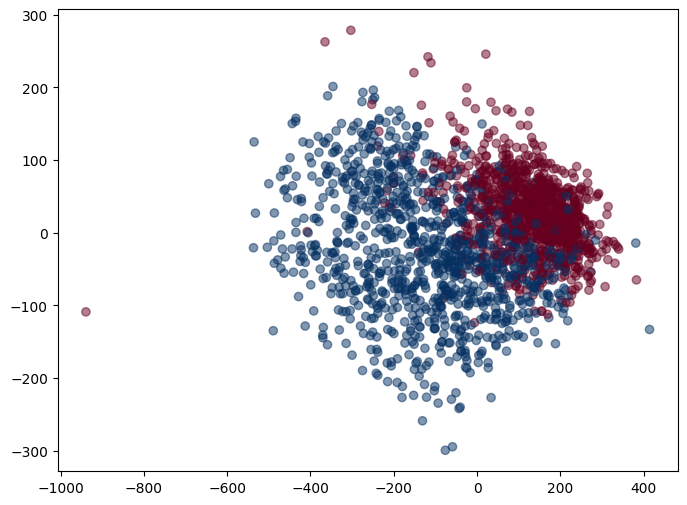

In [16]:
genre1 = cleaned_tracks["track", "genre_top"] == "Instrumental"
genre2 = cleaned_tracks["track", "genre_top"] == "Hip-Hop"

X = cleaned_features.loc[genre1 | genre2, "mfcc"]
X = skl.decomposition.PCA(n_components=2).fit_transform(X)

y = cleaned_tracks.loc[genre1 | genre2, ("track", "genre_top")]
y = skl.preprocessing.LabelEncoder().fit_transform(y)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", alpha=0.5)
X.shape, y.shape

### Non-linear parameter reduction

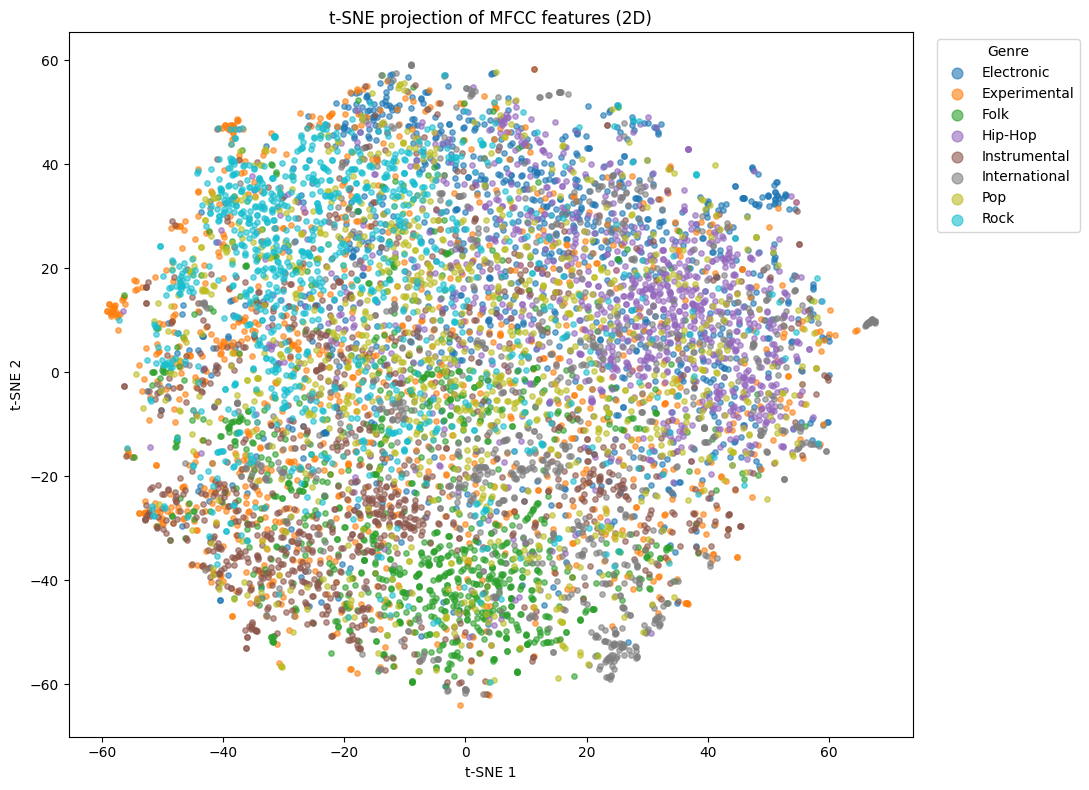

In [17]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Scale MFCC before t-SNE (sensitive to feature magnitudes)
X_mfcc_scaled = StandardScaler().fit_transform(cleaned_features["mfcc"].values)
y_genres = cleaned_tracks["track", "genre_top"].values
genre_cats = np.sort(np.unique(y_genres))

tsne = TSNE(
    n_components=2, random_state=42, perplexity=30, n_iter_without_progress=1000
)
X_tsne = tsne.fit_transform(X_mfcc_scaled)

colors = plt.cm.tab10(np.linspace(0, 1, len(genre_cats)))
fig, ax = plt.subplots(figsize=(11, 8))
for genre, color in zip(genre_cats, colors):
    mask = y_genres == genre
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1], label=genre, alpha=0.6, s=15, color=color
    )

ax.legend(markerscale=2, title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_title("t-SNE projection of MFCC features (2D)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


### CLAP embeddings

In [19]:
# CLAP (Contrastive Language-Audio Pretraining) — 512-dim audio embeddings
CLAP_MODEL_NAME = "laion/clap-htsat-unfused"
CLAP_SR = 48_000  # CLAP requires 48 kHz audio

if COMPUTE_CLAP_FEATURES:
    import torch
    from transformers import ClapModel, ClapProcessor

    _clap_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Loading CLAP model on {_clap_device}...")
    _clap_model = ClapModel.from_pretrained(CLAP_MODEL_NAME).to(_clap_device).eval()
    _clap_processor = ClapProcessor.from_pretrained(CLAP_MODEL_NAME)

    def compute_clap_embedding(tid: int):
        try:
            filepath = get_audio_path(AUDIO_DIR, tid)
            audio, _ = librosa.load(filepath, sr=CLAP_SR, mono=True)
            inputs = _clap_processor(
                audio=audio, return_tensors="pt", sampling_rate=CLAP_SR
            ).to(_clap_device)
            with torch.no_grad():
                # Go through audio_model + projection directly.
                # get_audio_features() returns BaseModelOutputWithPooling in some
                # transformers versions instead of a plain tensor.
                audio_out = _clap_model.audio_model(
                    input_features=inputs["input_features"],
                    is_longer=inputs.get("is_longer"),
                )
                emb = _clap_model.audio_projection(audio_out.pooler_output)
            return emb.detach().cpu().numpy().squeeze()
        except Exception as e:
            print(f"{tid}: {repr(e)}")
            return None

    clap_rows = {}
    for tid in tqdm(cleaned_tracks.index, desc="CLAP embeddings"):
        emb = compute_clap_embedding(tid)
        if emb is not None:
            clap_rows[tid] = emb

    clap_df = pd.DataFrame.from_dict(clap_rows, orient="index")
    clap_df.index.name = "track_id"
    clap_df.to_csv("./data/clap_embeddings.csv", float_format="%.8e")
    print(f"CLAP embeddings saved: {clap_df.shape}")

else:
    try:
        clap_df = pd.read_csv("./data/clap_embeddings.csv", index_col=0)
        print(f"Loaded CLAP embeddings: {clap_df.shape}")
    except FileNotFoundError:
        print(
            "No CLAP embeddings found. Set COMPUTE_CLAP_FEATURES = True to generate them."
        )
        clap_df = None

if clap_df is not None:
    clap_df = clap_df.loc[clap_df.index.intersection(cleaned_tracks.index)]
    print(f"Aligned with cleaned tracks: {clap_df.shape}")
    display(clap_df.head())


Loading CLAP model on cuda...


CLAP embeddings:   1%|          | 95/7996 [00:15<21:34,  6.11it/s] 


KeyboardInterrupt: 

## Preparing datasets 

### Time-based split

In [ ]:
y_all = cleaned_tracks["track", "genre_top"].values
dates = cleaned_tracks["track", "date_created"]
date_cutoff = dates.quantile(0.8)

idx_time_train = np.where(dates.values <= date_cutoff)[0]
idx_time_test = np.where(dates.values > date_cutoff)[0]

print(f"Date cutoff: {date_cutoff.date()}")
print(f"Train: {len(idx_time_train)}, Test: {len(idx_time_test)}")

X_mfcc_all = cleaned_features["mfcc"].values
X_full_all = features.loc[cleaned_tracks.index].values

time_datasets = {
    "MFCC (140d)": {
        "X_train": X_mfcc_all[idx_time_train],
        "X_test": X_mfcc_all[idx_time_test],
        "y_train": y_all[idx_time_train],
        "y_test": y_all[idx_time_test],
    },
    "Full (518d)": {
        "X_train": X_full_all[idx_time_train],
        "X_test": X_full_all[idx_time_test],
        "y_train": y_all[idx_time_train],
        "y_test": y_all[idx_time_test],
    },
}

if clap_df is not None:
    ct_clap = cleaned_tracks.loc[cleaned_tracks.index.isin(clap_df.index)]
    X_clap_all = clap_df.loc[ct_clap.index].values
    y_clap_all = ct_clap["track", "genre_top"].values
    dates_clap = ct_clap["track", "date_created"]
    cutoff_clap = dates_clap.quantile(0.8)
    idx_c_tr = np.where(dates_clap.values <= cutoff_clap)[0]
    idx_c_te = np.where(dates_clap.values > cutoff_clap)[0]
    time_datasets["CLAP (512d)"] = {
        "X_train": X_clap_all[idx_c_tr],
        "X_test": X_clap_all[idx_c_te],
        "y_train": y_clap_all[idx_c_tr],
        "y_test": y_clap_all[idx_c_te],
    }

for name, d in time_datasets.items():
    n_tr = len(d["X_train"])
    n_te = len(d["X_test"])
    print(f"  {name}: train={n_tr}, test={n_te}")


### Random split

In [ ]:
def make_random_split(X, y, test_size=0.2, seed=42):
    from sklearn.model_selection import train_test_split as _tts

    Xtr, Xte, ytr, yte = _tts(X, y, test_size=test_size, random_state=seed, stratify=y)
    return {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte}


random_datasets = {
    "MFCC (140d)": make_random_split(
        cleaned_features["mfcc"].values,
        cleaned_tracks["track", "genre_top"].values,
    ),
    "Full (518d)": make_random_split(
        features.loc[cleaned_tracks.index].values,
        cleaned_tracks["track", "genre_top"].values,
    ),
}

if clap_df is not None:
    ct_clap = cleaned_tracks.loc[cleaned_tracks.index.isin(clap_df.index)]
    y_clap_all = ct_clap["track", "genre_top"].values
    random_datasets["CLAP (512d)"] = make_random_split(
        clap_df.loc[ct_clap.index].values, y_clap_all
    )

# Unified dict keyed by (split_name, feature_name)
all_datasets = {
    **{("time", name): d for name, d in time_datasets.items()},
    **{("random", name): d for name, d in random_datasets.items()},
}

print("Dataset variants:")
for (split, feat), d in all_datasets.items():
    n_tr = len(d["X_train"])
    n_te = len(d["X_test"])
    print(f"  [{split:6s}] {feat}: train={n_tr:4d}, test={n_te:4d}")


## Classification

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

X = cleaned_features["mfcc"].values
y = cleaned_tracks["track", "genre_top"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest - Confusion Matrix (all genres)")
plt.tight_layout()

### SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
)

svm_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=42),
        ),
    ]
)

_d = random_datasets["MFCC (140d)"]
svm_pipe.fit(_d["X_train"], _d["y_train"])
y_pred_svm = svm_pipe.predict(_d["X_test"])
y_proba_svm = svm_pipe.predict_proba(_d["X_test"])

print("SVM (RBF, C=10) — MFCC 140d, random split")
print(classification_report(_d["y_test"], y_pred_svm))

_classes_svm = np.sort(np.unique(_d["y_test"]))
_y_bin_svm = label_binarize(_d["y_test"], classes=_classes_svm)
svm_results = {
    "Features": "MFCC (140d, raw)",
    "Split": "random",
    "Model": "SVM",
    "F1 (macro)": f1_score(_d["y_test"], y_pred_svm, average="macro"),
    "AUROC (macro)": roc_auc_score(
        _y_bin_svm, y_proba_svm, average="macro", multi_class="ovr"
    ),
    "Precision (macro)": precision_score(_d["y_test"], y_pred_svm, average="macro"),
    "Recall (macro)": recall_score(_d["y_test"], y_pred_svm, average="macro"),
    "Train time (s)": np.nan,
}

_cm_svm = confusion_matrix(_d["y_test"], y_pred_svm, labels=_classes_svm)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    _cm_svm.astype(float) / _cm_svm.sum(axis=1, keepdims=True),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=_classes_svm,
    yticklabels=_classes_svm,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("SVM — Confusion Matrix (MFCC 140d, random split)")
plt.tight_layout()


### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
)

_le_lgb = skl.preprocessing.LabelEncoder()
_d = random_datasets["MFCC (140d)"]
_ytr = _le_lgb.fit_transform(_d["y_train"])
_yte = _le_lgb.transform(_d["y_test"])

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(_d["X_train"], _ytr)
_pred_enc = lgbm.predict(_d["X_test"])
y_proba_lgbm = lgbm.predict_proba(_d["X_test"])
y_pred_lgbm = _le_lgb.inverse_transform(_pred_enc)

print("LightGBM — MFCC 140d, random split")
print(classification_report(_d["y_test"], y_pred_lgbm))

_classes_lgb = _le_lgb.classes_
_y_bin_lgb = label_binarize(_d["y_test"], classes=_classes_lgb)
lgbm_results = {
    "Features": "MFCC (140d, raw)",
    "Split": "random",
    "Model": "LightGBM",
    "F1 (macro)": f1_score(_d["y_test"], y_pred_lgbm, average="macro"),
    "AUROC (macro)": roc_auc_score(
        _y_bin_lgb, y_proba_lgbm, average="macro", multi_class="ovr"
    ),
    "Precision (macro)": precision_score(_d["y_test"], y_pred_lgbm, average="macro"),
    "Recall (macro)": recall_score(_d["y_test"], y_pred_lgbm, average="macro"),
    "Train time (s)": np.nan,
}

_cm_lgb = confusion_matrix(_d["y_test"], y_pred_lgbm, labels=_classes_lgb)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    _cm_lgb.astype(float) / _cm_lgb.sum(axis=1, keepdims=True),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=_classes_lgb,
    yticklabels=_classes_lgb,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("LightGBM — Confusion Matrix (MFCC 140d, random split)")
plt.tight_layout()


### CNN on Mel Spectrograms

> Full implementation in the *CNN on Mel Spectrograms* section below.


### MFCC vs full features, random vs time-based split

Two feature sets:
- MFCC -  (140d, self-computed)
- Full features (518d, from `features.csv`)

Both reduced to 100 dimensions via **Kernel PCA** for nonlinear dimensionality reduction. 

Models: Logistic Regression (multinomial) and Random Forest. Evaluated against two splits: random and time-based

In [ ]:
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)
from sklearn.base import clone
import time

# feature set 1: self-computed MFCC (140d)
X_mfcc = cleaned_features["mfcc"].values

# feature set 2: precomputed full features (518d)
X_full = features.loc[cleaned_tracks.index].values

y = cleaned_tracks["track", "genre_top"].values
classes = np.sort(np.unique(y))
dates = cleaned_tracks["track", "date_created"]

feature_sets = {
    "MFCC (140d)": X_mfcc,
    "Full (518d)": X_full,
}

print(f"\nFeature sets: {[(k, v.shape) for k, v in feature_sets.items()]}")
print(f"Classes: {classes}")

In [ ]:
# split 1: Random stratified 80/20
idx_all = np.arange(len(y))
idx_rand_train, idx_rand_test = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=y
)

# split 2: Time-based (80th percentile cutoff)
date_cutoff = dates.quantile(0.8)
idx_time_train = np.where(dates.values <= date_cutoff)[0]
idx_time_test = np.where(dates.values > date_cutoff)[0]

splits = {
    "random": (idx_rand_train, idx_rand_test),
    "time": (idx_time_train, idx_time_test),
}

for name, (tr, te) in splits.items():
    print(f"{name} split: train={len(tr)}, test={len(te)}")
    unique, counts = np.unique(y[te], return_counts=True)
    for g, c in zip(unique, counts):
        print(f"  {g}: {c}")

In [ ]:
N_COMPONENTS = 100

reduced_data = {}

for feat_name, X_raw in feature_sets.items():
    for split_name, (train_idx, test_idx) in splits.items():
        X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale (fit on train only)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw)
        X_test_scaled = scaler.transform(X_test_raw)

        # Kernel PCA (fit on train only)
        n_comp = min(N_COMPONENTS, X_train_scaled.shape[1])
        kpca = KernelPCA(n_components=n_comp, kernel="rbf", random_state=42, n_jobs=-1)
        X_train_red = kpca.fit_transform(X_train_scaled)
        X_test_red = kpca.transform(X_test_scaled)

        key = (feat_name, split_name)
        reduced_data[key] = (X_train_red, X_test_red, y_train, y_test)

        eigvals = kpca.eigenvalues_
        cumulative = np.cumsum(eigvals) / np.sum(eigvals)
        print(f"[{feat_name}, {split_name}] {X_train_raw.shape[1]}d -> {n_comp}d")

#### Model training and evaluation

- Logistic Regression (multinomial, L2)
- Random Forest on the 100 Kernel PCA components.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        solver="lbfgs", max_iter=1000, C=1.0, random_state=42, n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, random_state=42, n_jobs=-1
    ),
}

results = []
fitted_models = {}

for (feat_name, split_name), (X_train, X_test, y_train, y_test) in reduced_data.items():
    for model_name, model_template in models.items():
        model = clone(model_template)

        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        y_test_bin = label_binarize(y_test, classes=classes)
        f1 = f1_score(y_test, y_pred, average="macro")
        auroc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
        precision = precision_score(y_test, y_pred, average="macro")
        recall = recall_score(y_test, y_pred, average="macro")

        results.append(
            {
                "Features": feat_name,
                "Split": split_name,
                "Model": model_name,
                "F1 (macro)": f1,
                "AUROC (macro)": auroc,
                "Precision (macro)": precision,
                "Recall (macro)": recall,
                "Train time (s)": train_time,
            }
        )

        fitted_models[(feat_name, split_name, model_name)] = (model, y_pred, y_proba)

        print(f"\n{'=' * 60}")
        print(f"  {feat_name} | {split_name} | {model_name}")
        print(f"{'=' * 60}")
        print(classification_report(y_test, y_pred, digits=3))

results_df = pd.DataFrame(results)

In [ ]:
results_df.style.format(
    {
        "F1 (macro)": "{:.3f}",
        "AUROC (macro)": "{:.3f}",
        "Precision (macro)": "{:.3f}",
        "Recall (macro)": "{:.3f}",
        "Train time (s)": "{:.1f}",
    }
).set_caption("Model Comparison: Kernel PCA (100 components) + LogReg / RF")

#### Confusion matrices

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

configs = [
    ("Full (518d)", "random", "Logistic Regression"),
    ("Full (518d)", "random", "Random Forest"),
    ("Full (518d)", "time", "Logistic Regression"),
    ("Full (518d)", "time", "Random Forest"),
]

for ax, (feat, split, model_name) in zip(axes.flat, configs):
    _, X_test, _, y_test = reduced_data[(feat, split)]
    model, y_pred, _ = fitted_models[(feat, split, model_name)]

    cm = confusion_matrix(y_test, y_pred, labels=classes)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name} | {split} split")

plt.suptitle(
    "Confusion Matrices — Full features (518d → 100d KPCA)", y=1.01, fontsize=14
)
plt.tight_layout()

#### Per-class F1: MFCC vs Full features

Comparing per-genre F1 for Random Forest on the random split to see which genres benefit most from the richer feature set.

In [ ]:
_, _, _, y_test_rand = reduced_data[("MFCC (140d)", "random")]

_, y_pred_mfcc_rf, _ = fitted_models[("MFCC (140d)", "random", "Random Forest")]
_, y_pred_mfcc_lr, _ = fitted_models[("MFCC (140d)", "random", "Logistic Regression")]
_, y_pred_full_rf, _ = fitted_models[("Full (518d)", "random", "Random Forest")]
_, y_pred_full_lr, _ = fitted_models[("Full (518d)", "random", "Logistic Regression")]

f1_mfcc_rf = f1_score(y_test_rand, y_pred_mfcc_rf, average=None, labels=classes)
f1_mfcc_lr = f1_score(y_test_rand, y_pred_mfcc_lr, average=None, labels=classes)
f1_full_rf = f1_score(y_test_rand, y_pred_full_rf, average=None, labels=classes)
f1_full_lr = f1_score(y_test_rand, y_pred_full_lr, average=None, labels=classes)

comparison = pd.DataFrame(
    {
        "RF (MFCC 140d)": f1_mfcc_rf,
        "LR (MFCC 140d)": f1_mfcc_lr,
        "RF (Full 518d)": f1_full_rf,
        "LR (Full 518d)": f1_full_lr,
    },
    index=classes,
)

comparison.plot(kind="bar", figsize=(12, 6), width=0.8)
plt.ylabel("F1 Score")
plt.title("Per-class F1: MFCC vs Full Features (random split, Kernel PCA 100d)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()

print(comparison.round(3).to_string())
print(
    f"\nMacro F1 — RF(MFCC): {f1_mfcc_rf.mean():.3f}, RF(Full): {f1_full_rf.mean():.3f}, LR(Full): {f1_full_lr.mean():.3f}"
)

### CNN on Mel Spectrograms

Pipeline: audio -> mel spectrogram (128 mel bands x ~1292 frames) -> CNN -> 8 genre classes

In [ ]:
import os

if GENERATE_SPECTROGRAMS:
    SPECTROGRAM_DIR = "./data/spectrograms"
    N_MELS = 128
    FIXED_LENGTH = 1292  # ~30s at sr=22050, hop_length=512

    os.makedirs(SPECTROGRAM_DIR, exist_ok=True)

    def extract_and_save_spectrogram(tid):
        filepath = get_audio_path(AUDIO_DIR, tid)
        x, sr = librosa.load(filepath, sr=None, mono=True)
        S = librosa.feature.melspectrogram(
            y=x, sr=sr, n_mels=N_MELS, n_fft=2048, hop_length=512
        )
        S_db = librosa.power_to_db(S, ref=np.max)

        # Pad or truncate to fixed length
        if S_db.shape[1] < FIXED_LENGTH:
            S_db = np.pad(S_db, ((0, 0), (0, FIXED_LENGTH - S_db.shape[1])))
        else:
            S_db = S_db[:, :FIXED_LENGTH]

        tid_str = f"{tid:06d}"
        np.save(
            os.path.join(SPECTROGRAM_DIR, f"{tid_str}.npy"), S_db.astype(np.float32)
        )

    for tid in tqdm(cleaned_tracks.index, desc="Extracting spectrograms"):
        try:
            out_path = os.path.join(SPECTROGRAM_DIR, f"{tid:06d}.npy")
            if not os.path.exists(out_path):
                extract_and_save_spectrogram(tid)
        except Exception as e:
            print(f"{tid}: {e}")

    print(f"Spectrograms saved to {SPECTROGRAM_DIR}/")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder


class MelSpectrogramDataset(Dataset):
    def __init__(self, track_ids, labels, spectrogram_dir):
        self.track_ids = track_ids
        self.labels = labels
        self.spectrogram_dir = spectrogram_dir

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        tid = self.track_ids[idx]
        path = os.path.join(self.spectrogram_dir, f"{tid:06d}.npy")
        S_db = np.load(path)

        # Normalize per-spectrogram
        S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)

        tensor = torch.tensor(S_db, dtype=torch.float32).unsqueeze(0)  # (1, 128, 1292)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return tensor, label

In [ ]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(cleaned_tracks["track", "genre_top"].values)
track_ids_arr = cleaned_tracks.index.values

ids_train, ids_test = train_test_split(
    np.arange(len(y_encoded)), test_size=0.2, random_state=42, stratify=y_encoded
)
y_train_cnn = y_encoded[ids_train]
y_test_cnn = y_encoded[ids_test]

train_dataset = MelSpectrogramDataset(
    track_ids_arr[ids_train], y_train_cnn, SPECTROGRAM_DIR
)
test_dataset = MelSpectrogramDataset(
    track_ids_arr[ids_test], y_test_cnn, SPECTROGRAM_DIR
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Classes: {le.classes_}")
print(f"Sample shape: {train_dataset[0][0].shape}")

In [ ]:
class GenreCNN(nn.Module):
    def __init__(self, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (1, 128, 1292) -> (32, 64, 646)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: (32, 64, 646) -> (64, 32, 323)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: (64, 32, 323) -> (128, 16, 161)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # (128, 1, 1) — global average pooling
            nn.Flatten(),  # 128
            nn.Dropout(0.5),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device(
    "gpu"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
model = GenreCNN(n_classes=len(le.classes_)).to(device)
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

N_EPOCHS = 20
train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in tqdm(
        train_loader, desc=f"Epoch {epoch + 1}/{N_EPOCHS}", leave=False
    ):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)

    val_loss /= len(test_dataset)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(
        f"Epoch {epoch + 1}/{N_EPOCHS}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, lr={optimizer.param_groups[0]['lr']:.1e}"
    )

#### CNN evaluation

In [ ]:
# Training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_EPOCHS + 1), train_losses, label="Train loss")
ax.plot(range(1, N_EPOCHS + 1), val_losses, label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CNN Training Curves")
ax.legend()
plt.tight_layout()

In [ ]:
# Evaluate on test set
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

cnn_f1 = f1_score(all_labels, all_preds, average="macro")
cnn_auroc = roc_auc_score(all_labels, all_probs, average="macro", multi_class="ovr")
cnn_precision = precision_score(all_labels, all_preds, average="macro")
cnn_recall = recall_score(all_labels, all_preds, average="macro")

print(classification_report(all_labels, all_preds, target_names=le.classes_, digits=3))

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("CNN — Confusion Matrix (random split)")
plt.tight_layout()

### Comparison

Summary of all models evaluated across feature sets and split strategies:

| Model | Feature Set | Split | Dim Reduction |
|-------|-------------|-------|---------------|
| SVM | MFCC (140d) | random | None |
| LightGBM | MFCC (140d) | random | None |
| Logistic Regression | MFCC (140d) / Full (518d) | random + time | Kernel PCA → 100d |
| Random Forest | MFCC (140d) / Full (518d) | random + time | Kernel PCA → 100d |
| CNN | Mel spectrogram (128×1292) | random | — |


In [ ]:
# ── Collect all results ───────────────────────────────────────────────────
cnn_row = {
    "Features": "Mel spectrogram",
    "Split": "random",
    "Model": "CNN",
    "F1 (macro)": cnn_f1,
    "AUROC (macro)": cnn_auroc,
    "Precision (macro)": cnn_precision,
    "Recall (macro)": cnn_recall,
    "Train time (s)": np.nan,
}

final_df = (
    pd.concat(
        [results_df, pd.DataFrame([svm_results, lgbm_results, cnn_row])],
        ignore_index=True,
    )
    .sort_values("F1 (macro)", ascending=False)
    .reset_index(drop=True)
)

# Styled table
display(
    final_df.style.format(
        {
            "F1 (macro)": "{:.3f}",
            "AUROC (macro)": "{:.3f}",
            "Precision (macro)": "{:.3f}",
            "Recall (macro)": "{:.3f}",
            "Train time (s)": "{:.1f}",
        },
        na_rep="-",
    )
    .background_gradient(subset=["F1 (macro)", "AUROC (macro)"], cmap="YlGn")
    .set_caption("Final Model Comparison — Music Genre Classification")
)

# ── Bar chart ─────────────────────────────────────────────────────────────
labels = [
    f"{r['Model']}\n{r['Features']}\n({r['Split']})" for _, r in final_df.iterrows()
]
colors = plt.cm.tab20(np.linspace(0, 1, len(final_df)))
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(np.arange(len(final_df)), final_df["F1 (macro)"].values, color=colors)
ax.set_xticks(np.arange(len(final_df)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.0)
ax.set_title("Macro F1 across all models and feature sets")
for bar, f1 in zip(bars, final_df["F1 (macro)"].values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{f1:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
plt.tight_layout()
plt.show()
